# Error Analysis — LightGBM (Optuna-Tuned) F1 Race Position Model

Goes beyond the single headline MAE (`lightgbm.ipynb` Section 11a, `reports/lightgbm_tuned_test_results.csv`) to check whether that error is spread evenly or concentrated in specific, actionable slices of the 2025 held-out test set. Four segmentations:

1. **Street vs. permanent circuits** — are the chaotic street tracks (Monaco, Baku, Singapore, …) harder to predict?
2. **Rain vs. dry (`RainRisk`)** — does the model degrade in wet races?
3. **Rookie vs. veteran drivers** — is the model biased for/against drivers with little history?
4. **Finishing-position tier** — does error concentrate at the front, back, or middle of the field?

None of these four dimensions exist as columns in `data/test.parquet` — `Meeting.Circuit.ShortName` is label-encoded, `round_number` is standardised, there's no rookie/debut flag, and weather was never joined into `FINAL_FEATURES` (see README "TODO" — `RainRisk` is computed in `reports/eda_fe.ipynb` but the modelling pipeline never loads it). Section 3 below reconstructs each of them from the saved preprocessors and raw partitions before any segmentation happens.

**Model**: the Optuna-tuned `LGBMRegressor` (`reports/lightgbm_best_params.json`), refit on the full 2019–2024 training set — the best model by test MAE among everything in `reports/lightgbm_tuned_test_results.csv`. All segments below are slices of the same 479-row 2025 test set; some slices are small (as few as ~60 rows), so treat magnitudes as directional, not precise.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from lightgbm import LGBMRegressor

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.feature_engineering.feature_engineering import FINAL_FEATURES, NUMERIC_SCALE_FEATURES, TARGET

# Palette (validated categorical/diverging pair, see .claude dataviz skill)
BLUE = "#2a78d6"
RED = "#e34948"
GRAY = "#898781"
INK = "#0b0b0b"


## 2. Load Data and Fit the Tuned Model

Same setup as `lightgbm.ipynb` Section 11a: refit `LGBMRegressor` with the winning Optuna hyperparameters on the full 2019–2024 training set and predict on the untouched 2025 test season.

In [2]:
train = pd.read_parquet("../data/train.parquet")
test = pd.read_parquet("../data/test.parquet")

with open("../data/features_preprocessors.pkl", "rb") as fh:
    preprocessors = pickle.load(fh)

with open("../reports/lightgbm_best_params.json") as fh:
    tuned_params = json.load(fh)["params"]

train_X, train_Y = train[FINAL_FEATURES], train[TARGET]
test_X, test_Y = test[FINAL_FEATURES], test[TARGET]

model = LGBMRegressor(random_state=42, verbose=-1, **tuned_params)
model.fit(train_X, train_Y)
test_preds = model.predict(test_X)

print(f"Fitted on {train_X.shape[0]} rows; analysing {test_X.shape[0]} held-out 2025 rows.")
print(f"Test MAE: {np.abs(test_preds - test_Y.values).mean():.3f}")

Fitted on 2556 rows; analysing 479 held-out 2025 rows.
Test MAE: 3.345


## 3. Reconstruct Real-World Values

`build_features()` (`pipeline/feature_engineering/feature_engineering.py`) label-encodes `TeamName`/`Meeting.Circuit.ShortName` to integers and standardises every column in `NUMERIC_SCALE_FEATURES` — including `round_number` — to zero mean / unit variance. That's correct for modelling but means `test["round_number"]` is a z-score, not a race number, and `test["Meeting.Circuit.ShortName"]` is an arbitrary integer code. Both need to be inverted using the exact `StandardScaler`/`LabelEncoder` objects saved to `data/features_preprocessors.pkl` during feature engineering — refitting a new scaler here would not reproduce the original mapping.

In [3]:
scaler = preprocessors["scaler"]
circuit_encoder = preprocessors["label_encoders"]["Meeting.Circuit.ShortName"]

raw_numeric = pd.DataFrame(
    scaler.inverse_transform(test[NUMERIC_SCALE_FEATURES]),
    columns=NUMERIC_SCALE_FEATURES,
    index=test.index,
)
raw_round_number = raw_numeric["round_number"].round().astype(int)

circuit = circuit_encoder.inverse_transform(test["Meeting.Circuit.ShortName"].astype(int))

analysis = pd.DataFrame({
    "year": test["year"].values,
    "round_number": raw_round_number.values,
    "DriverId": test["DriverId"].values,
    "circuit": circuit,
    "actual": test_Y.values,
    "pred": test_preds,
})
analysis["signed_error"] = analysis["pred"] - analysis["actual"]
analysis["abs_error"] = analysis["signed_error"].abs()

print(f"Reconstructed round numbers: {raw_round_number.min()}-{raw_round_number.max()} "
      f"({raw_round_number.nunique()} unique rounds)")
analysis.head()

Reconstructed round numbers: 1-24 (24 unique rounds)


,year,round_number,DriverId,circuit,actual,pred,signed_error,abs_error
0,2025,1,albon,Melbourne,5.0,11.206508,6.206508,6.206508
1,2025,2,albon,Shanghai,7.0,12.501629,5.501629,5.501629
2,2025,3,albon,Suzuka,9.0,10.081623,1.081623,1.081623
3,2025,4,albon,Sakhir,12.0,13.245515,1.245515,1.245515
4,2025,5,albon,Jeddah,9.0,12.371433,3.371433,3.371433


## 4. Overall Error (Baseline for Every Segment Below)

Sign convention: `signed_error = pred - actual`. **Positive** = the model predicted a *worse* (higher-numbered) finishing position than the driver actually achieved (over-pessimistic). **Negative** = the model predicted a *better* finishing position than reality (over-optimistic).

In [4]:
overall_mae = analysis["abs_error"].mean()
overall_bias = analysis["signed_error"].mean()
print(f"Overall  MAE: {overall_mae:.3f}   bias: {overall_bias:+.3f}   n={len(analysis)}")

Overall  MAE: 3.345   bias: -0.073   n=479


## 5. Segment — Street vs. Permanent Circuits

There's no "circuit type" field anywhere in the ingested data — only the circuit *name*. Street circuits are manually classified by general F1 knowledge (temporary tracks laid out on public roads, run only once a year): **Baku, Jeddah, Las Vegas, Miami, Monte Carlo (Monaco), Singapore, and Melbourne** (Albert Park is a temporary street circuit through a public park, not a permanent racing facility). Every other circuit in the 2025 calendar is a permanent, purpose-built racing facility.

In [5]:
STREET_CIRCUITS = {"Baku", "Jeddah", "Las Vegas", "Miami", "Monte Carlo", "Singapore", "Melbourne"}

analysis["circuit_type"] = np.where(analysis["circuit"].isin(STREET_CIRCUITS), "Street", "Permanent")

circuit_type_summary = analysis.groupby("circuit_type").agg(
    n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("signed_error", "mean"),
).round(3)
circuit_type_summary

,n,MAE,bias
circuit_type,,,
Permanent,339,3.433,-0.075
Street,140,3.132,-0.071


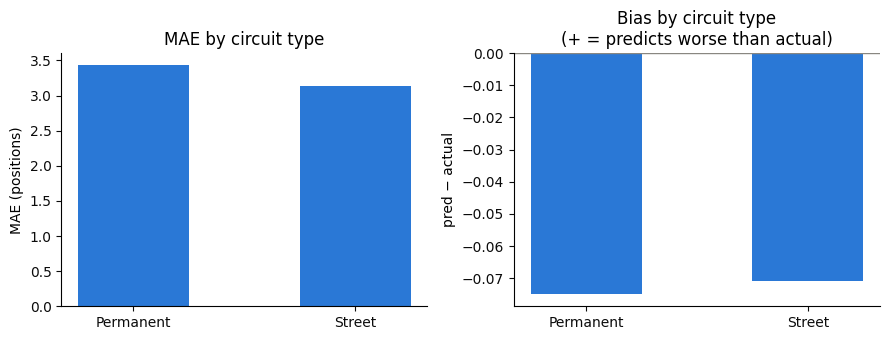

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(circuit_type_summary.index, circuit_type_summary["MAE"], color=BLUE, width=0.5)
axes[0].set_title("MAE by circuit type")
axes[0].set_ylabel("MAE (positions)")

colors = [RED if b > 0 else BLUE for b in circuit_type_summary["bias"]]
axes[1].bar(circuit_type_summary.index, circuit_type_summary["bias"], color=colors, width=0.5)
axes[1].axhline(0, color=GRAY, linewidth=1)
axes[1].set_title("Bias by circuit type\n(+ = predicts worse than actual)")
axes[1].set_ylabel("pred − actual")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK)

plt.tight_layout()
plt.show()

## 6. Segment — Rain vs. Dry (`RainRisk`)

`RainRisk` (fraction of weather-telemetry readings during the race with `Rainfall=True`) is computed in `reports/eda_fe.ipynb` but — per the README TODO — `build_features()` never joins weather into `FINAL_FEATURES`, so it doesn't exist in `test.parquet`. Reconstructed here directly from the raw `session=R` `weather.parquet` partitions for each of the 24 rounds of the 2025 test season, using the same `mean(Rainfall)` definition as the EDA notebook.

In [7]:
weather_rows = []
for round_number in sorted(analysis["round_number"].unique()):
    weather_path = Path(f"../data/year=2025/round={round_number:02d}/session=R/weather.parquet")
    weather = pq.ParquetFile(weather_path).read().to_pandas()
    weather_rows.append({"round_number": round_number, "RainRisk": weather["Rainfall"].mean()})

rain_risk = pd.DataFrame(weather_rows).sort_values("RainRisk", ascending=False)
rain_risk

,round_number,RainRisk
12,13,0.457399
0,1,0.325843
11,12,0.180645
17,18,0.037267
5,6,0.033557
9,10,0.005988
2,3,0.000000
1,2,0.000000
7,8,0.000000
6,7,0.000000


`RainRisk` is heavily zero-inflated (most 2025 races were fully dry) with a long tail of a few genuinely wet races and a couple of marginal, single-digit-percent readings (rounds with `RainRisk` ≈ 0.03–0.04 — a few brief wet-radar blips, not a wet race). Two thresholds are compared: a loose `> 0` cut (any rain detected at all, 6 of 24 races) and a stricter `> 0.05` cut (meaningfully wet races, 3 of 24 races) to check whether the marginal rounds are diluting the signal.

In [8]:
analysis = analysis.merge(rain_risk, on="round_number", how="left")

rain_segment_summaries = {}
for threshold in [0.0, 0.05]:
    label = f"RainRisk > {threshold}"
    analysis[label] = np.where(analysis["RainRisk"] > threshold, "Rain", "Dry")
    summary = analysis.groupby(label).agg(
        n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("signed_error", "mean"),
    ).round(3)
    rain_segment_summaries[label] = summary
    print(f"--- {label} ---")
    print(summary, "\n")

--- RainRisk > 0.0 ---
                  n    MAE   bias
RainRisk > 0.0                   
Dry             359  3.372 -0.071
Rain            120  3.263 -0.082 

--- RainRisk > 0.05 ---
                   n    MAE   bias
RainRisk > 0.05                   
Dry              419  3.287 -0.082
Rain              60   3.75 -0.013 



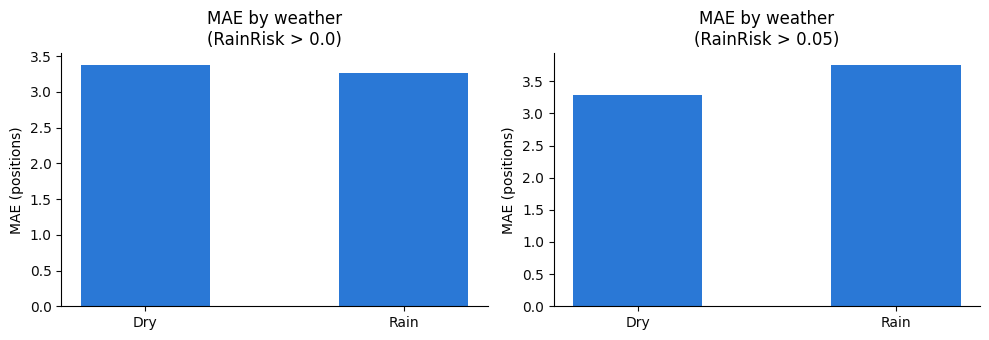

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, (label, summary) in zip(axes, rain_segment_summaries.items()):
    ax.bar(summary.index, summary["MAE"], color=BLUE, width=0.5)
    ax.set_title(f"MAE by weather\n({label})")
    ax.set_ylabel("MAE (positions)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK)

plt.tight_layout()
plt.show()

## 7. Segment — Rookie vs. Veteran Drivers

No debut-year or experience field exists anywhere in the ingested data. The proxy used here: **cumulative races completed by each driver across the full ingested dataset (2019–2025), strictly before the race being predicted** — a driver with fewer than 22 prior races (roughly one full season) is tagged `rookie`, everyone else `veteran`.

**Caveat**: the ingested dataset starts in 2019, so a driver whose real career began earlier (e.g. Hamilton, debut 2007) is under-counted for *2019* races specifically. That doesn't bias the segmentation below, though — every driver racing in the **2025** test season who was already on the grid in 2019 has accrued 6 seasons (120+ races) of in-dataset history by then, so the 2019 floor only affects analysis of 2019 itself, not the test set used here.

In [10]:
ROOKIE_THRESHOLD_RACES = 22  # ~1 season

full_history = pd.concat([
    pd.DataFrame({
        "year": train["year"].values,
        "round_number": pd.DataFrame(
            scaler.inverse_transform(train[NUMERIC_SCALE_FEATURES]), columns=NUMERIC_SCALE_FEATURES,
        )["round_number"].round().astype(int).values,
        "DriverId": train["DriverId"].values,
    }),
    pd.DataFrame({
        "year": analysis["year"].values,
        "round_number": analysis["round_number"].values,
        "DriverId": analysis["DriverId"].values,
    }),
], ignore_index=True).sort_values(["DriverId", "year", "round_number"]).reset_index(drop=True)

full_history["prior_races"] = full_history.groupby("DriverId").cumcount()
prior_races_lookup = full_history.set_index(["DriverId", "year", "round_number"])["prior_races"]

analysis = analysis.join(prior_races_lookup, on=["DriverId", "year", "round_number"])
analysis["experience"] = np.where(
    analysis["prior_races"] < ROOKIE_THRESHOLD_RACES, "Rookie", "Veteran"
)

rookie_drivers = sorted(analysis.loc[analysis["experience"] == "Rookie", "DriverId"].unique())
print(f"2025 drivers tagged rookie (<{ROOKIE_THRESHOLD_RACES} prior races in dataset): {rookie_drivers}")

experience_summary = analysis.groupby("experience").agg(
    n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("signed_error", "mean"),
).round(3)
experience_summary

2025 drivers tagged rookie (<22 prior races in dataset): ['antonelli', 'bearman', 'bortoleto', 'colapinto', 'doohan', 'hadjar', 'lawson']


,n,MAE,bias
experience,,,
Rookie,115,3.17,-0.54
Veteran,364,3.4,0.074


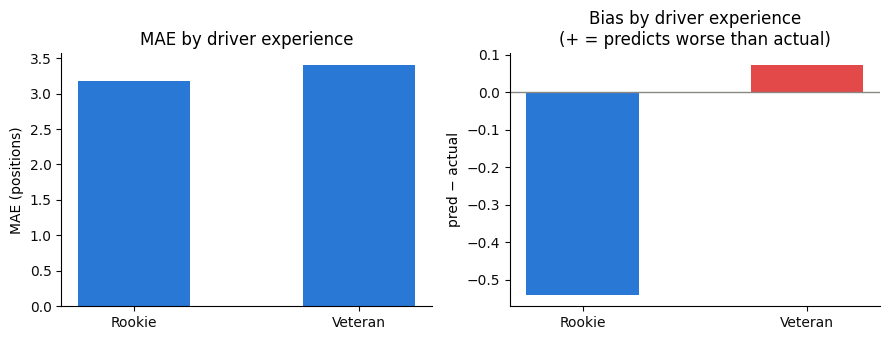

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(experience_summary.index, experience_summary["MAE"], color=BLUE, width=0.5)
axes[0].set_title("MAE by driver experience")
axes[0].set_ylabel("MAE (positions)")

colors = [RED if b > 0 else BLUE for b in experience_summary["bias"]]
axes[1].bar(experience_summary.index, experience_summary["bias"], color=colors, width=0.5)
axes[1].axhline(0, color=GRAY, linewidth=1)
axes[1].set_title("Bias by driver experience\n(+ = predicts worse than actual)")
axes[1].set_ylabel("pred − actual")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK)

plt.tight_layout()
plt.show()

## 8. Segment — Finishing-Position Tier

Unlike the previous three segments, this one needs no reconstruction — `actual` (the true `RacePosition`) is already on its native 1–20 scale. Binned into four tiers: podium, points-paying midfield, non-scoring midfield, and back of the grid.

In [12]:
def position_tier(position: float) -> str:
    if position <= 3:
        return "Podium (1-3)"
    if position <= 10:
        return "Points (4-10)"
    if position <= 15:
        return "Midfield (11-15)"
    return "Back (16-20)"

TIER_ORDER = ["Podium (1-3)", "Points (4-10)", "Midfield (11-15)", "Back (16-20)"]

analysis["position_tier"] = analysis["actual"].apply(position_tier)

tier_summary = analysis.groupby("position_tier").agg(
    n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("signed_error", "mean"),
).round(3).reindex(TIER_ORDER)
tier_summary

,n,MAE,bias
position_tier,,,
Podium (1-3),72,3.166,3.153
Points (4-10),168,3.052,2.703
Midfield (11-15),120,1.589,-0.379
Back (16-20),119,5.637,-5.637


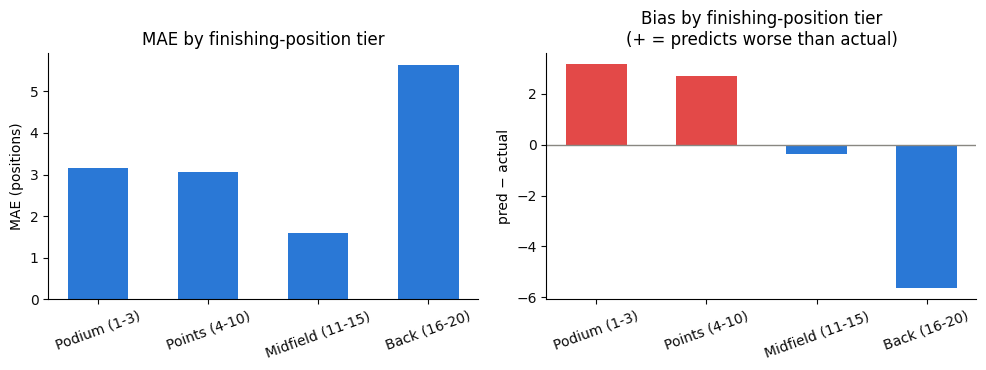

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].bar(tier_summary.index, tier_summary["MAE"], color=BLUE, width=0.55)
axes[0].set_title("MAE by finishing-position tier")
axes[0].set_ylabel("MAE (positions)")
axes[0].tick_params(axis="x", rotation=20)

colors = [RED if b > 0 else BLUE for b in tier_summary["bias"]]
axes[1].bar(tier_summary.index, tier_summary["bias"], color=colors, width=0.55)
axes[1].axhline(0, color=GRAY, linewidth=1)
axes[1].set_title("Bias by finishing-position tier\n(+ = predicts worse than actual)")
axes[1].set_ylabel("pred − actual")
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK)

plt.tight_layout()
plt.show()

## 9. Save Segment Summaries

In [14]:
segment_summary = pd.concat([
    circuit_type_summary.assign(segment="circuit_type"),
    rain_segment_summaries["RainRisk > 0.0"].assign(segment="rain_gt_0"),
    rain_segment_summaries["RainRisk > 0.05"].assign(segment="rain_gt_0.05"),
    experience_summary.assign(segment="experience"),
    tier_summary.assign(segment="position_tier"),
]).rename_axis("group").reset_index()

segment_summary.to_csv("../reports/error_analysis_segments.csv", index=False)
segment_summary

,group,n,MAE,bias,segment
0,Permanent,339,3.433,-0.075,circuit_type
1,Street,140,3.132,-0.071,circuit_type
2,Dry,359,3.372,-0.071,rain_gt_0
3,Rain,120,3.263,-0.082,rain_gt_0
4,Dry,419,3.287,-0.082,rain_gt_0.05
5,Rain,60,3.75,-0.013,rain_gt_0.05
6,Rookie,115,3.17,-0.54,experience
7,Veteran,364,3.4,0.074,experience
8,Podium (1-3),72,3.166,3.153,position_tier
9,Points (4-10),168,3.052,2.703,position_tier


## 10. Takeaways

- **Position tier is the dominant error driver — far larger than any of the domain segments.** The model shows textbook **regression to the mean**: podium finishers are under-predicted (bias ≈ +3.15 — the model expects a worse finish than they actually achieve) and back-of-grid finishers are massively over-predicted (bias ≈ −5.64 — the model expects a far better finish than reality). MAE for the back tier (≈5.6) is more than **3x** the midfield tier's MAE (≈1.6), which is itself nearly unbiased. A single overall MAE of 3.34 hides this: the model is considerably more trustworthy for midfield predictions than for the extremes.
- **Rookies get a lower MAE but a much larger, more one-sided bias than veterans.** Rookie MAE (≈3.17) is actually *below* veteran MAE (≈3.40), but rookie bias (≈−0.54) is far more negative than veteran bias (≈+0.07) — the model is systematically over-optimistic about rookies, predicting better finishes than they go on to achieve. Plausible cause: a rookie's lag/EWM form features are median-imputed or based on very few real races (`_impute_nulls` / short `DriverFinish_roll3_inseason` history in `feature_engineering.py`), so the model leans more on `GridPosition`/`TeamFinish_*`, which doesn't capture a rookie's typically rougher first season.
- **Rain is only a problem in genuinely wet races, not any detectable rain.** At a strict "meaningfully wet" threshold (`RainRisk > 0.05`, 3 of 24 races) MAE is clearly worse in the rain (≈3.75 vs ≈3.29 dry). At a loose "any rain at all" threshold (`RainRisk > 0`, 6 of 24 races, including marginal single-digit-percent readings) that gap nearly vanishes (≈3.26 vs ≈3.37) — the effect is driven by the truly wet races, diluted by including borderline ones. Small sample (3-6 races) — directional, not conclusive.
- **Street vs. permanent circuits shows no meaningful gap** (MAE ≈3.13 street vs ≈3.43 permanent, bias comparable) — contrary to the intuition that chaotic street races (safety cars, walls, Monaco's single-file track) would be harder to predict. `GridPosition` and the team/driver form features apparently transfer just as well to street tracks in this dataset.
- **Practical implication**: if this model informs any downstream decision, position-tier is the split to design around first — e.g. a separate correction/calibration step for the front and back of the field would likely help more than tuning for any single domain segment (weather, circuit type, or experience) above.